# Meridionally Equidistant Polyconic Projection
# (Park Polyconic Projection)

Meridionally Equidistant Polyconic Projection is a map projection that produces a world map with an inverted teardrop-shaped outline. This projection was designed to address a known limitation of the American polyconic projection, in which the total length of meridians increases as one moves away from the central meridian. While mitigating this meridional distortion, the projection preserves the regularity of parallels in a polyconic-like geometric framework.

The projection was developed by Donghwi Park during his Ph.D. coursework period in 2019, but was not formally published at that time.

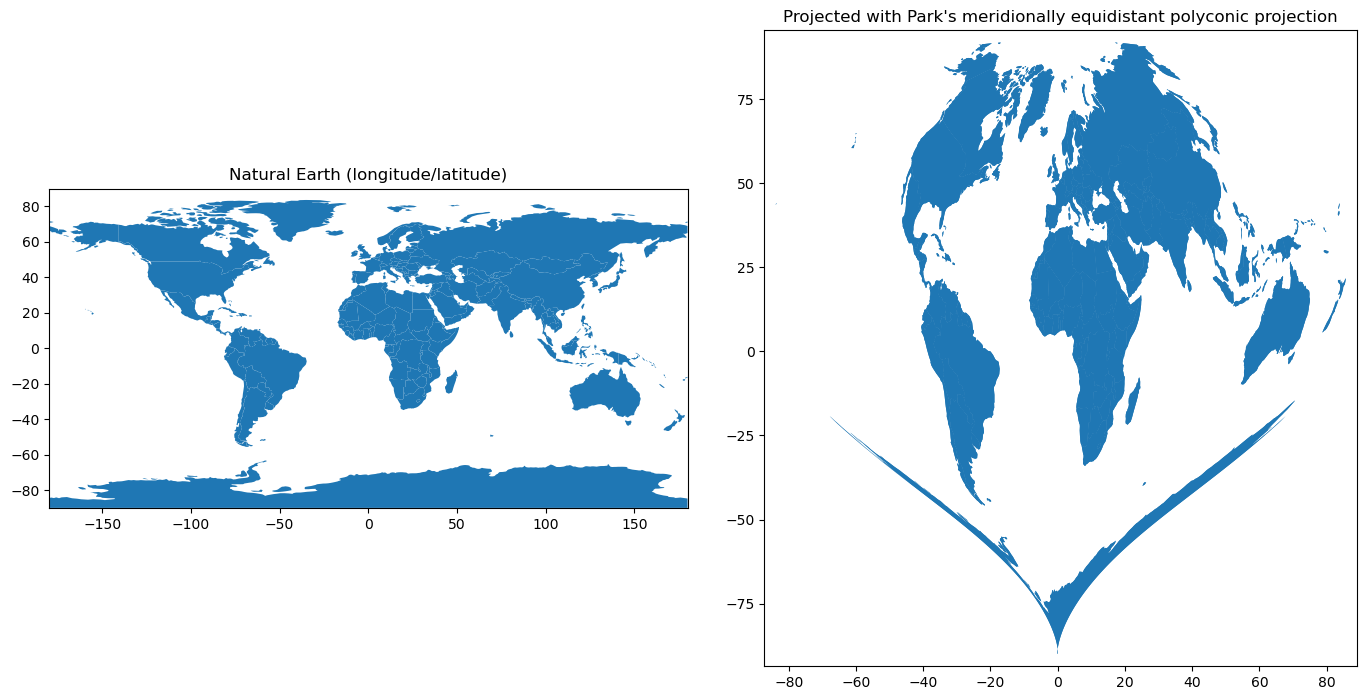

Saved: /mnt/data/park_polyconic_world_map1.png
Saved: /mnt/data/park_polyconic_world_map1.pdf


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, LineString, MultiLineString, GeometryCollection
from shapely.ops import transform

def densify_coords(coords, max_step=0.25):
    new = []
    coords = list(coords)

    for (x0, y0), (x1, y1) in zip(coords[:-1], coords[1:]):
        new.append((x0, y0))
        dist = max(abs(x1 - x0), abs(y1 - y0))
        n = max(1, int(np.ceil(dist / max_step)))
        for k in range(1, n):
            t = k / n
            new.append((x0 + t * (x1 - x0), y0 + t * (y1 - y0)))

    new.append(coords[-1])
    return new

def densify_polygon(poly, max_step=0.25):
    exterior = densify_coords(poly.exterior.coords, max_step)
    interiors = [densify_coords(ring.coords, max_step) for ring in poly.interiors]
    return Polygon(exterior, interiors)

def densify_geom(geom, max_step=0.25):
    if geom.geom_type == "Polygon":
        return densify_polygon(geom, max_step)
    elif geom.geom_type == "MultiPolygon":
        return MultiPolygon([densify_polygon(g, max_step) for g in geom.geoms])
    else:
        return geom



# --- Projection grid from the user's code ---
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

# --- Bilinear interpolation on the precomputed grid ---
def project_point(lon, lat):
    # Clamp to valid input domain
    lon = float(np.clip(lon, -180.0, 180.0))
    lat = float(np.clip(lat, -90.0, 90.0))

    # Grid coordinates:
    # rows: 90 -> -90 by 1 degree
    # cols: 0 -> 180 by 0.5 degree, stored as 0..360
    row = 90.0 - lat
    col = abs(lon) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon < 0:
        x = -x

    return x, y

# Shapely transform helper
def proj_transform(x, y, z=None):
    # shapely sends arrays
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    out_x = np.empty_like(x)
    out_y = np.empty_like(y)

    for i in range(len(x)):
        px, py = project_point(x[i], y[i])
        out_x[i] = px
        out_y[i] = py

    if z is None:
        return out_x, out_y
    return out_x, out_y, z

# --- Load a local Natural Earth low-res world shapefile ---
#shp_path = "/opt/pyvenv/lib/python3.13/site-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp"
#world = gpd.read_file(shp_path)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
# Project geometries



world2 = world.copy()

antarctica_mask = world2["ADMIN"].eq("Antarctica") | world2["NAME"].eq("Antarctica")

world2.loc[antarctica_mask, "geometry"] = world2.loc[
    antarctica_mask, "geometry"
].apply(lambda g: densify_geom(g, max_step=0.25))

projected_geoms = world2.geometry.apply(lambda geom: transform(proj_transform, geom))





# --- Make figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: original lon/lat
world.plot(ax=axes[0], linewidth=0.5)
axes[0].set_title("Natural Earth (longitude/latitude)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)

# Right: projected
gpd.GeoSeries(projected_geoms, crs=None).plot(ax=axes[1], linewidth=0.5)
axes[1].set_title("Projected with Park's meridionally equidistant polyconic projection")
axes[1].set_aspect("equal", adjustable="box")

proj_series = gpd.GeoSeries(projected_geoms, crs=None)
proj_series.plot(ax=axes[1], linewidth=0.5)

minx, miny, maxx, maxy = proj_series.total_bounds
pad_x = (maxx - minx) * 0.02
pad_y = (maxy - miny) * 0.02
axes[1].set_xlim(minx - pad_x, maxx + pad_x)
axes[1].set_ylim(miny - pad_y, maxy + pad_y)


for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

png_path = "/mnt/data/park_polyconic_world_map1.png"
pdf_path = "/mnt/data/park_polyconic_world_map1.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")


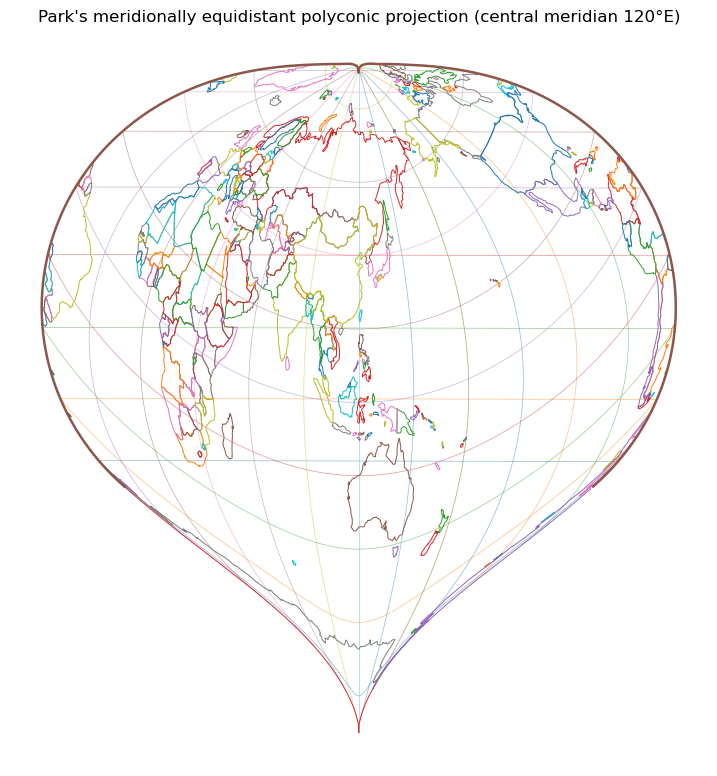

Saved: /mnt/data/park_polyconic_120E_boundary.png
Saved: /mnt/data/park_polyconic_120E_boundary.pdf


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# -----------------------------
# 1) Build the projection grid
# -----------------------------
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

# --------------------------------------------
# 2) Bilinear interpolation on the projection
#    with a movable central meridian
# --------------------------------------------
CENTRAL_MERIDIAN = 120.0  # east longitude

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    """Return longitude relative to the chosen central meridian in [-180, 180]."""
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0  # 0.5° columns

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# ----------------------------------------
# 3) Convert polygon rings to safe lines
#    split at the projection seam
# ----------------------------------------
def densify_segment(p0, p1, max_step_deg=1.0):
    lon0, lat0 = p0
    lon1, lat1 = p1
    n = max(1, int(np.ceil(max(abs(lon1 - lon0), abs(lat1 - lat0)) / max_step_deg)))
    pts = []
    for k in range(n):
        t = k / n
        lon = lon0 + t * (lon1 - lon0)
        lat = lat0 + t * (lat1 - lat0)
        pts.append((lon, lat))
    return pts

def ring_to_projected_segments(coords, lon0=CENTRAL_MERIDIAN, max_step_deg=1.0):
    coords = list(coords)
    if len(coords) < 2:
        return []

    # Densify first, to reduce jaggedness
    dense = []
    for i in range(len(coords) - 1):
        dense.extend(densify_segment(coords[i], coords[i + 1], max_step_deg=max_step_deg))
    dense.append(coords[-1])

    segments = []
    current = []

    prev_rel = None
    for lon, lat in dense:
        rel = wrap_lon_relative(lon, lon0)

        # Split when crossing the cut line (jump near ±180° after wrapping)
        if prev_rel is not None and abs(rel - prev_rel) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = []

        x, y = project_point(lon, lat, lon0)
        current.append((x, y))
        prev_rel = rel

    if len(current) >= 2:
        segments.append(current)

    return segments

def extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN):
    segments = []

    if isinstance(geom, Polygon):
        segments.extend(ring_to_projected_segments(geom.exterior.coords, lon0=lon0))
        for interior in geom.interiors:
            segments.extend(ring_to_projected_segments(interior.coords, lon0=lon0))

    elif isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            segments.extend(extract_segments_from_geom(poly, lon0=lon0))

    return segments

# -----------------------------
# 4) Load world polygons
# -----------------------------
#shp_path = "/opt/pyvenv/lib/python3.13/site-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp"
#world = gpd.read_file(shp_path)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
# Build projected coastline/boundary line segments
all_segments = []
for geom in world.geometry:
    all_segments.extend(extract_segments_from_geom(geom, lon0=CENTRAL_MERIDIAN))

# ---------------------------------
# 5) Outer boundary of the projection
# ---------------------------------
# The outer boundary is the right edge (lon_rel = +180) mirrored to the left.
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

# Also prepare a few graticule lines for reference
graticule_parallels = []
for lat in range(-80, 81, 20):
    lons = np.linspace(-180, 180, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lon in lons]
    graticule_parallels.append(np.array(pts))

graticule_meridians = []
for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = [project_point(lon, lat, CENTRAL_MERIDIAN) for lat in lats]
    graticule_meridians.append(np.array(pts))

# -----------------------------
# 6) Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(9, 10))

# light graticule
for arr in graticule_parallels:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)
for arr in graticule_meridians:
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.5, alpha=0.5)

# coastlines / borders as linework only
for seg in all_segments:
    arr = np.asarray(seg)
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.7)

# projection boundary
ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Park's meridionally equidistant polyconic projection (central meridian 120°E)")
ax.set_axis_off()

png_path = "/mnt/data/park_polyconic_120E_boundary.png"
pdf_path = "/mnt/data/park_polyconic_120E_boundary.pdf"
fig.savefig(png_path, dpi=240, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")


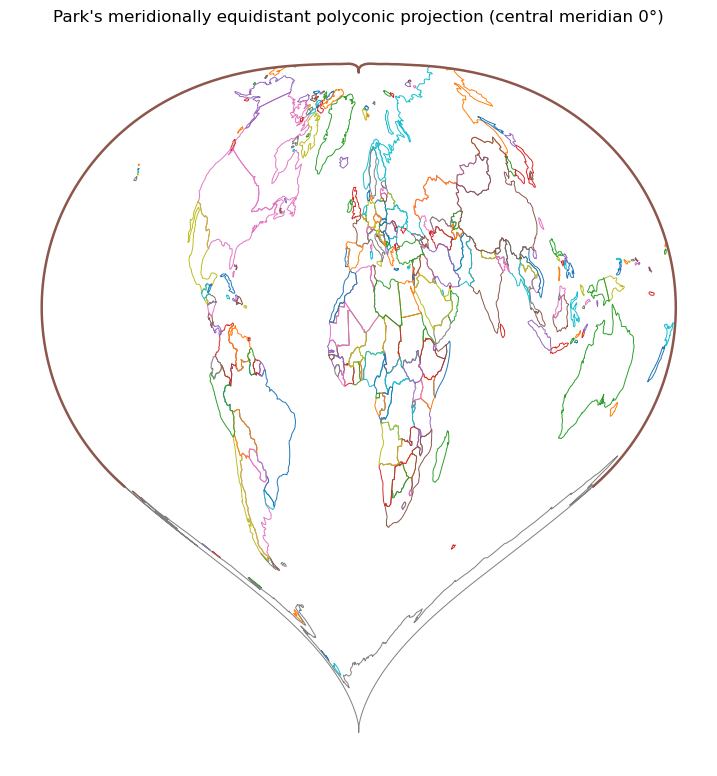

/mnt/data/park_polyconic_0E_world.png
/mnt/data/park_polyconic_0E_world.pdf


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon

# -----------------------------
# 1) Build the projection grid
# -----------------------------
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

CENTRAL_MERIDIAN = 0.0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = np.clip(lat, -90.0, 90.0)

    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# Coastline extraction as lines
# -----------------------------
def densify_segment(p0, p1, max_step_deg=1.0):
    lon0, lat0 = p0
    lon1, lat1 = p1
    n = max(1, int(np.ceil(max(abs(lon1 - lon0), abs(lat1 - lat0)) / max_step_deg)))
    pts = []
    for k in range(n):
        t = k / n
        lon = lon0 + t * (lon1 - lon0)
        lat = lat0 + t * (lat1 - lat0)
        pts.append((lon, lat))
    return pts

def ring_to_segments(coords):
    coords = list(coords)
    if len(coords) < 2:
        return []
    dense = []
    for i in range(len(coords) - 1):
        dense.extend(densify_segment(coords[i], coords[i + 1]))
    dense.append(coords[-1])

    segments = []
    current = []
    prev_rel = None

    for lon, lat in dense:
        rel = wrap_lon_relative(lon)
        if prev_rel is not None and abs(rel - prev_rel) > 180:
            if len(current) >= 2:
                segments.append(current)
            current = []
        x, y = project_point(lon, lat)
        current.append((x, y))
        prev_rel = rel

    if len(current) >= 2:
        segments.append(current)
    return segments

def extract_segments(geom):
    segs = []
    if isinstance(geom, Polygon):
        segs.extend(ring_to_segments(geom.exterior.coords))
        for interior in geom.interiors:
            segs.extend(ring_to_segments(interior.coords))
    elif isinstance(geom, MultiPolygon):
        for g in geom.geoms:
            segs.extend(extract_segments(g))
    return segs

# Load world
#shp_path = "/opt/pyvenv/lib/python3.13/site-packages/pyogrio/tests/fixtures/naturalearth_lowres/naturalearth_lowres.shp"
#world = gpd.read_file(shp_path)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"

all_segments = []
for geom in world.geometry:
    all_segments.extend(extract_segments(geom))

# Boundary
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

# Plot
fig, ax = plt.subplots(figsize=(9, 10))

for seg in all_segments:
    arr = np.array(seg)
    ax.plot(arr[:, 0], arr[:, 1], linewidth=0.7)

ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect("equal", adjustable="box")
ax.set_title("Park's meridionally equidistant polyconic projection (central meridian 0°)")
ax.set_axis_off()


png = "/mnt/data/park_polyconic_0E_world.png"
pdf = "/mnt/data/park_polyconic_0E_world.pdf"
plt.savefig(png, dpi=240, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print(png)
print(pdf)

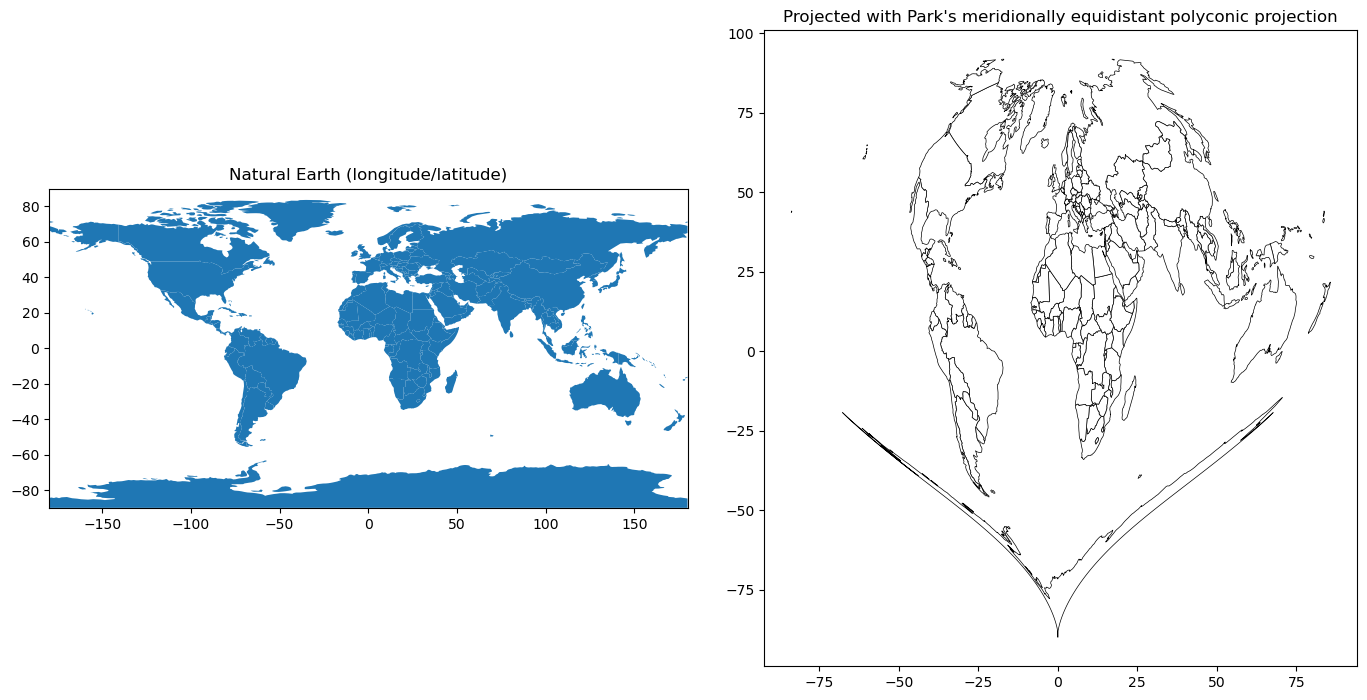

Saved: /mnt/data/park_polyconic_world_map2.png
Saved: /mnt/data/park_polyconic_world_map2.pdf


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.ops import transform

# --- Projection grid from the user's code ---
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

# --- Bilinear interpolation on the precomputed grid ---
def project_point(lon, lat):
    lon = float(np.clip(lon, -180.0, 180.0))
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon < 0:
        x = -x

    return x, y

def proj_transform(x, y, z=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    out_x = np.empty_like(x)
    out_y = np.empty_like(y)

    for i in range(len(x)):
        px, py = project_point(x[i], y[i])
        out_x[i] = px
        out_y[i] = py

    if z is None:
        return out_x, out_y
    return out_x, out_y, z

# --- Densify helper: 남극만 경계점을 촘촘하게 ---
def densify_geom(geom, max_segment_length=0.5):
    # shapely 2.x 의 segmentize 사용
    # 0.5 degree 정도면 꽤 자연스러워짐
    return geom.segmentize(max_segment_length)

# --- Load world data ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 남극 분리
antarctica = world[world["NAME"] == "Antarctica"].copy()
others = world[world["NAME"] != "Antarctica"].copy()

# 일반 국가 투영
others_proj = others.geometry.apply(lambda geom: transform(proj_transform, geom))

# 남극만 densify 후 투영
antarctica_dense = antarctica.geometry.apply(lambda geom: densify_geom(geom, max_segment_length=0.25))
antarctica_proj = antarctica_dense.apply(lambda geom: transform(proj_transform, geom))

# --- Make figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: original lon/lat
world.plot(ax=axes[0], linewidth=0.5)
axes[0].set_title("Natural Earth (longitude/latitude)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)

# Right: projected
gpd.GeoSeries(others_proj, crs=None).plot(ax=axes[1], linewidth=0.5, color="white", edgecolor="black")
gpd.GeoSeries(antarctica_proj, crs=None).plot(ax=axes[1], linewidth=0.5, color="white", edgecolor="black")

axes[1].set_title("Projected with Park's meridionally equidistant polyconic projection")
axes[1].set_aspect("equal", adjustable="box")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

png_path = "/mnt/data/park_polyconic_world_map2.png"
pdf_path = "/mnt/data/park_polyconic_world_map2.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

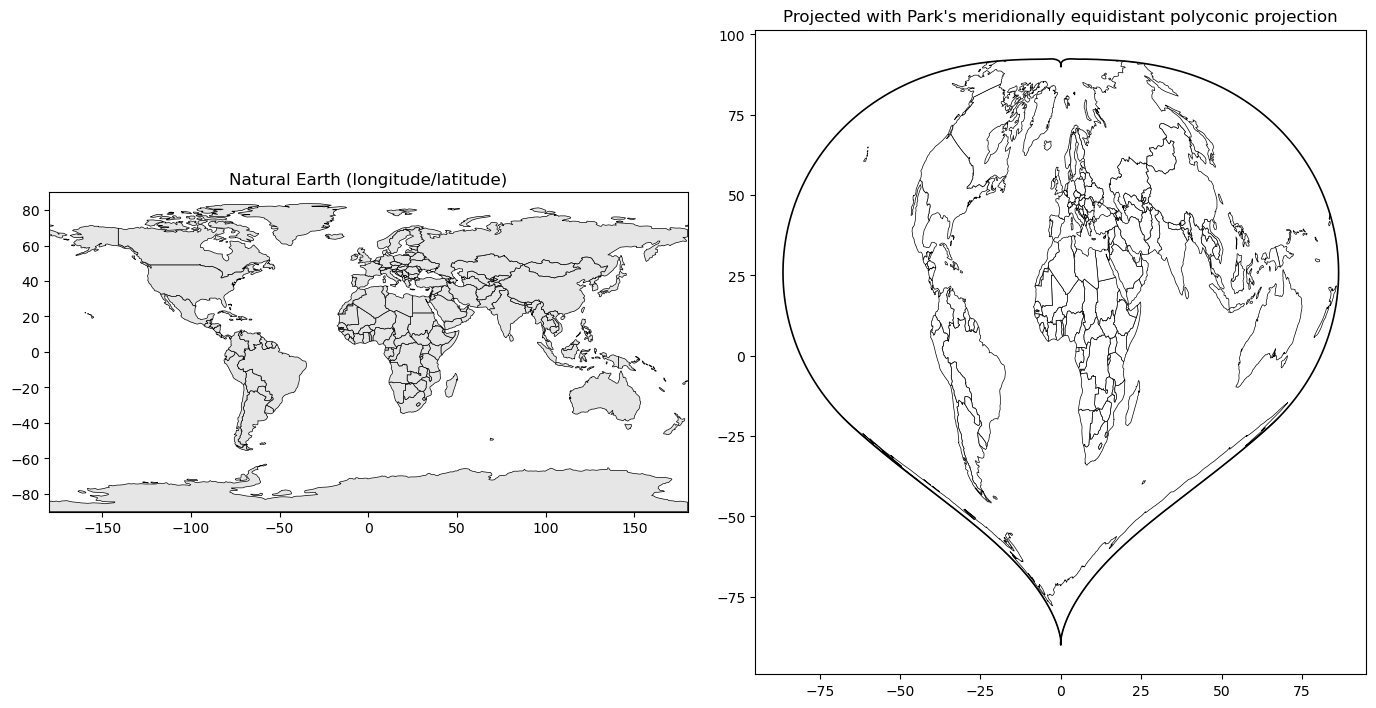

Saved: /mnt/data/park_polyconic_world_map3.png
Saved: /mnt/data/park_polyconic_world_map3.pdf


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.ops import transform

# --- Projection grid from the user's code ---
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))

    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )

        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)

        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)

        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

# --- Bilinear interpolation on the precomputed grid ---
def project_point(lon, lat):
    lon = float(np.clip(lon, -180.0, 180.0))
    lat = float(np.clip(lat, -90.0, 90.0))

    row = 90.0 - lat
    col = abs(lon) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon < 0:
        x = -x

    return x, y

def proj_transform(x, y, z=None):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    out_x = np.empty_like(x)
    out_y = np.empty_like(y)

    for i in range(len(x)):
        px, py = project_point(x[i], y[i])
        out_x[i] = px
        out_y[i] = py

    if z is None:
        return out_x, out_y
    return out_x, out_y, z

# --- Densify helper (Shapely 2.x) ---
def densify_geom(geom, max_segment_length=0.25):
    return geom.segmentize(max_segment_length)

# --- Projection boundary ---
def projection_boundary(n=2000):
    # 외곽은 대체로
    # 북극 점 -> 오른쪽 바깥 경계(lon=180) -> 남극 쪽 -> 아래쪽(lat=-90) -> 왼쪽 바깥 경계(lon=-180) -> 북극 점
    lats_right = np.linspace(90, -90, n)
    right = np.array([project_point(180, lat) for lat in lats_right])

    lons_bottom = np.linspace(180, -180, 2 * n)
    bottom = np.array([project_point(lon, -90) for lon in lons_bottom])

    lats_left = np.linspace(-90, 90, n)
    left = np.array([project_point(-180, lat) for lat in lats_left])

    boundary = np.vstack([right, bottom[1:], left[1:]])
    return boundary[:, 0], boundary[:, 1]

# --- Load world data ---
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

# 남극 분리
antarctica = world[world["NAME"] == "Antarctica"].copy()
others = world[world["NAME"] != "Antarctica"].copy()

# 일반 국가 투영
others_proj = others.geometry.apply(lambda geom: transform(proj_transform, geom))

# 남극은 더 촘촘하게 만든 뒤 투영
antarctica_dense = antarctica.geometry.apply(lambda geom: densify_geom(geom, max_segment_length=0.15))
antarctica_proj = antarctica_dense.apply(lambda geom: transform(proj_transform, geom))

# 외곽선
bx, by = projection_boundary()

# --- Make figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Left: original lon/lat
world.plot(
    ax=axes[0],
    linewidth=0.5,
    facecolor="0.9",
    edgecolor="black"
)
axes[0].set_title("Natural Earth (longitude/latitude)")
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlim(-180, 180)
axes[0].set_ylim(-90, 90)

# Right: projected
gpd.GeoSeries(others_proj, crs=None).plot(
    ax=axes[1],
    linewidth=0.5,
    facecolor="white",
    edgecolor="black"
)

# 남극을 따로 채색
gpd.GeoSeries(antarctica_proj, crs=None).plot(
    ax=axes[1],
    linewidth=0.5,
    facecolor="white",   # 남극 채색
    edgecolor="black",
    zorder=3
)

# 도법 외곽 경계선
axes[1].plot(bx, by, linewidth=1.2, color="black", zorder=5)

axes[1].set_title("Projected with Park's meridionally equidistant polyconic projection")
axes[1].set_aspect("equal", adjustable="box")

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()

png_path = "/mnt/data/park_polyconic_world_map3.png"
pdf_path = "/mnt/data/park_polyconic_world_map3.pdf"
fig.savefig(png_path, dpi=220, bbox_inches="tight")
fig.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved: {png_path}")
print(f"Saved: {pdf_path}")

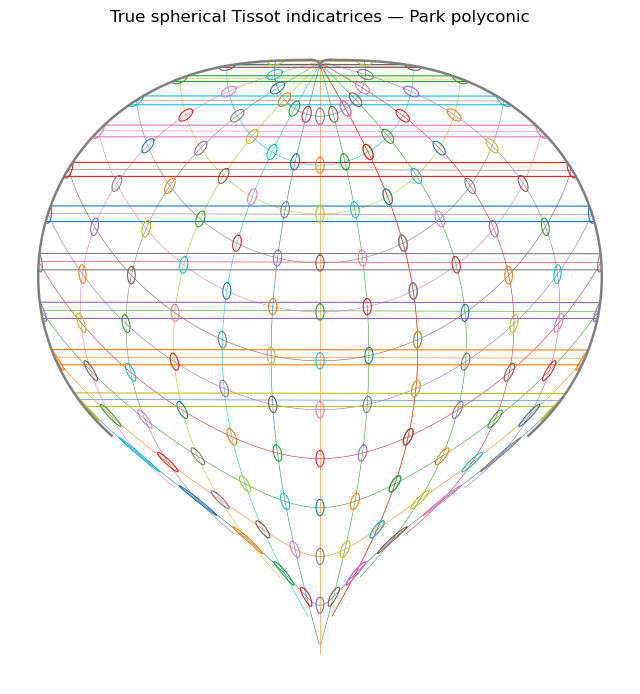

/mnt/data/park_polyconic_true_tissot.png
/mnt/data/park_polyconic_true_tissot.pdf


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Build the projection grid
# -----------------------------
def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

X = np.zeros((181, 362))
Y = np.zeros((181, 362))

Y[0, :] = 90
for A in range(0, 361):
    X[1, A] = sind(A / 2)
    Y[1, A] = 90 - cosd(A / 2)

for A in range(0, 181):
    Y[A, 0] = 90 - A

nerbi = cosd(0.25) * sind(0.25) / (1 - cosd(1))

for a in range(1, 180):
    A_mat = a + 1
    tempnerbi = nerbi * (cosd(A_mat) - cosd(A_mat + 1))
    for b in range(0, 360):
        tempnerbi2 = tempnerbi + (
            (Y[a + 1, b] - Y[a, b]) * (X[a, b + 1] - X[a, b])
            - (Y[a, b + 1] - Y[a, b]) * (X[a + 1, b] - X[a, b])
        )
        dx_diag = X[a + 1, b] - X[a, b + 1]
        dy_diag = Y[a + 1, b] - Y[a, b + 1]
        templength = np.sqrt(dy_diag**2 + dx_diag**2)
        tempsintheta = np.clip(tempnerbi2 / templength, -1.0, 1.0)
        tempcostheta = np.sqrt(1 - tempsintheta**2)
        X[a + 1, b + 1] = X[a, b + 1] + (
            tempcostheta * (X[a + 1, b] - X[a, b + 1])
            - tempsintheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength
        Y[a + 1, b + 1] = Y[a, b + 1] + (
            tempsintheta * (X[a + 1, b] - X[a, b + 1])
            + tempcostheta * (Y[a + 1, b] - Y[a, b + 1])
        ) / templength

Xp = X[:, :361]
Yp = Y[:, :361]

CENTRAL_MERIDIAN = 120.0

def wrap_lon_relative(lon, lon0=CENTRAL_MERIDIAN):
    return ((lon - lon0 + 180.0) % 360.0) - 180.0

def project_point(lon, lat, lon0=CENTRAL_MERIDIAN):
    lon_rel = wrap_lon_relative(lon, lon0)
    lat = np.clip(lat, -90.0, 90.0)
    row = 90.0 - lat
    col = abs(lon_rel) * 2.0

    r0 = int(np.floor(row))
    c0 = int(np.floor(col))
    r1 = min(r0 + 1, 180)
    c1 = min(c0 + 1, 360)

    tr = row - r0
    tc = col - c0

    x00, x01 = Xp[r0, c0], Xp[r0, c1]
    x10, x11 = Xp[r1, c0], Xp[r1, c1]
    y00, y01 = Yp[r0, c0], Yp[r0, c1]
    y10, y11 = Yp[r1, c0], Yp[r1, c1]

    x = (
        (1 - tr) * (1 - tc) * x00
        + (1 - tr) * tc * x01
        + tr * (1 - tc) * x10
        + tr * tc * x11
    )
    y = (
        (1 - tr) * (1 - tc) * y00
        + (1 - tr) * tc * y01
        + tr * (1 - tc) * y10
        + tr * tc * y11
    )

    if lon_rel < 0:
        x = -x

    return x, y

# -----------------------------
# 2) True spherical small circles
# -----------------------------
def spherical_small_circle(lon0_deg, lat0_deg, radius_deg=3.0, n=180):
    """
    True small circle on the sphere:
    all points at angular distance radius_deg from (lon0_deg, lat0_deg).
    """
    lon0 = np.deg2rad(lon0_deg)
    lat0 = np.deg2rad(lat0_deg)
    r = np.deg2rad(radius_deg)

    pts = []
    thetas = np.linspace(0, 2*np.pi, n, endpoint=True)
    sin_lat0 = np.sin(lat0)
    cos_lat0 = np.cos(lat0)
    sin_r = np.sin(r)
    cos_r = np.cos(r)

    for theta in thetas:
        lat = np.arcsin(sin_lat0 * cos_r + cos_lat0 * sin_r * np.cos(theta))
        lon = lon0 + np.arctan2(
            np.sin(theta) * sin_r * cos_lat0,
            cos_r - sin_lat0 * np.sin(lat)
        )
        pts.append((np.rad2deg(lon), np.rad2deg(lat)))
    return pts

def projected_tissot(lon0, lat0, radius_deg=3.0, n=180):
    sph = spherical_small_circle(lon0, lat0, radius_deg=radius_deg, n=n)
    arr = np.array([project_point(lon, lat, CENTRAL_MERIDIAN) for lon, lat in sph])
    return arr

# -----------------------------
# 3) Boundary
# -----------------------------
boundary_x = np.concatenate([-Xp[::-1, 360], Xp[:, 360]])
boundary_y = np.concatenate([Yp[::-1, 360], Yp[:, 360]])

# -----------------------------
# 4) Plot true Tissot indicatrices
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 10))

# draw a few graticule lines for orientation
for lat in range(-75, 76, 15):
    lons = np.linspace(-180, 180, 721)
    pts = np.array([project_point(lon, lat, CENTRAL_MERIDIAN) for lon in lons])
    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)

for lon in range(-180, 181, 30):
    lats = np.linspace(-90, 90, 721)
    pts = np.array([project_point(lon, lat, CENTRAL_MERIDIAN) for lat in lats])
    ax.plot(pts[:, 0], pts[:, 1], linewidth=0.4)

# true Tissot indicatrices
for lat in range(-75, 76, 15):
    for lon in range(-180, 181, 30):
        ell = projected_tissot(lon, lat, radius_deg=2.5, n=160)
        ax.plot(ell[:, 0], ell[:, 1], linewidth=0.8)

# boundary
ax.plot(boundary_x, boundary_y, linewidth=1.8)

ax.set_aspect('equal')
ax.axis('off')
ax.set_title("True spherical Tissot indicatrices — Park polyconic")

png = "/mnt/data/park_polyconic_true_tissot.png"
pdf = "/mnt/data/park_polyconic_true_tissot.pdf"
plt.savefig(png, dpi=240, bbox_inches='tight')
plt.savefig(pdf, bbox_inches='tight')
plt.show()

print(png)
print(pdf)
